In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import torch.nn.functional as F


### Part 4 — Training setup (device + hyperparameters)

- **Device**
  - Selects GPU if available, otherwise CPU:
    - `device = "cuda"` if possible, else `"cpu"`

- **Core GAN hyperparameters**
  - `latent_dim = 100`: size of the noise vector \(z \sim \mathcal{N}(0, I)\) fed into the Generator.
  - `batch_size = 128`: number of MNIST images per training step.
  - `epochs = 40`: number of full passes over the dataset.

- **Optimization**
  - `lr = 0.0002`: learning rate commonly used for GAN training on MNIST.
  - `beta1 = 0.5`: Adam momentum parameter (DCGAN-style) that often improves GAN stability compared to the default 0.9.


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

latent_dim = 100
batch_size = 128
epochs = 40
lr = 0.0002
beta1 = 0.5


### Part 4 — MNIST data loading + normalization (match Generator output)

- **Transforms**
  - `ToTensor()` converts images to tensors in the range **[0, 1]**.
  - `Normalize((0.5,), (0.5,))` maps pixels to **[-1, 1]** using:
    \[
    x_{norm} = \frac{x - 0.5}{0.5}
    \]
  - This is important because the Generator ends with **`Tanh()`**, which also outputs values in **[-1, 1]**.  
    ✅ So the real data distribution and fake data distribution are on the same scale.

- **Dataset + DataLoader**
  - Loads the MNIST training set (downloads if missing).
  - `shuffle=True` ensures batches are randomized each epoch, improving GAN training stability.


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


### Part 4A — Generator network (noise → fake MNIST image)

- The **Generator (G)** maps a random latent vector \(z \in \mathbb{R}^{100}\) into a 28×28 image.

- **Architecture**
  - A fully-connected (MLP) generator with progressive expansion:
    - 100 → 256 → 512 → 1024 → 784
  - Each hidden block uses:
    - `BatchNorm1d`: stabilizes training and improves gradient flow
    - `ReLU`: nonlinearity

- **Output layer**
  - Final layer outputs 784 values and applies **`Tanh()`**:
    - output range becomes **[-1, 1]**
  - This matches the MNIST preprocessing normalization (real images are also scaled to [-1, 1]).

- **Reshape**
  - The output is reshaped into image format:
    - `(-1, 1, 28, 28)` → one grayscale MNIST image per sample.

✅ This satisfies requirement **A: Implement the Generator network**.


In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


### Part 4B — Discriminator network (image → real/fake probability)

- The **Discriminator (D)** is a binary classifier that predicts whether an input image is:
  - **real** (from MNIST) or
  - **fake** (generated by G)

- **Architecture**
  - Input image is flattened: 28×28 → 784
  - Fully-connected layers:
    - 784 → 512 → 256 → 1
  - Uses **LeakyReLU(0.2)** to avoid “dead neurons” and improve gradient flow (common GAN practice).

- **Output**
  - Final layer applies **Sigmoid**, producing a probability in **[0, 1]**:
    - close to 1 → predicted real
    - close to 0 → predicted fake

✅ This satisfies requirement **B: Implement the Discriminator network**.


In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


### Part 4 — Initialize GAN components (models, loss, optimizers)

- **Model initialization**
  - Instantiate the Generator `G` and Discriminator `D` and move them to the selected device (CPU/GPU).

- **Loss function**
  - `criterion = nn.BCELoss()` (binary cross-entropy) is used because:
    - the Discriminator outputs a probability via `Sigmoid`
    - the task is binary classification: real vs fake

- **Optimizers**
  - Both networks use Adam:
    - `lr = 0.0002`
    - `betas = (0.5, 0.999)` (DCGAN-style setting)
  - Separate optimizers are used because G and D have different objectives and are updated in alternating steps.

✅ After this cell, the GAN training loop can alternate:
- update D to classify real/fake correctly
- update G to fool D (make fake look real)


In [6]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))


### Part 4C — GAN training loop (alternate D and G updates) + loss behavior

- **What this loop does**
  - Trains the GAN for `epochs=40` by alternating:
    1) **Discriminator update**: learn to classify real MNIST as 1 and generated images as 0  
    2) **Generator update**: learn to generate images that the Discriminator classifies as 1

- **Step 1: Train Discriminator (D)**
  - Sample noise: \( z \sim \mathcal{N}(0, I) \)
  - Generate fake images: `fake = G(z)`
  - Compute D outputs:
    - `D_real = D(real)` should be close to 1
    - `D_fake = D(fake.detach())` should be close to 0  
      (`detach()` prevents gradients flowing into G while training D)
  - Discriminator loss:
    \[
    \mathcal{L}_D = BCE(D(x_{real}), 1) + BCE(D(x_{fake}), 0)
    \]
  - Update `opt_D`.

- **Step 2: Train Generator (G)**
  - Re-evaluate `D(fake)` (without detach)
  - Generator loss (non-saturating form):
    \[
    \mathcal{L}_G = BCE(D(x_{fake}), 1)
    \]
  - Update `opt_G`.

- **Loss tracking**
  - We store final batch losses each epoch into:
    - `losses_d`, `losses_g`
  - And print epoch-level progress.

---

#### Reported results (this run)
- Early training shows instability (normal for GANs), e.g.:
  - Epoch 3: **D Loss = 1.6737**, **G Loss = 2.5138**
- Later epochs stabilize around:
  - **D Loss ≈ 1.25–1.38**
  - **G Loss ≈ 0.70–1.00**

✅ Interpretation:
- The losses do not steadily decrease like supervised learning (GAN training is a min–max game).
- The relatively stable range later suggests the adversarial game reached a rough balance:
  - D is not collapsing to perfect classification (which would make G gradients vanish)
  - G is not trivially fooling D (which would make D loss explode)

📌 Note (small improvement for reporting):
- Currently, `losses_d/g` store only the **last batch** loss of each epoch.  
  For smoother curves, you can average loss over all batches in the epoch, but this is optional unless the assignment specifically asks for loss curves.


In [7]:
losses_g, losses_d = [], []

for epoch in range(epochs):
    for real, _ in loader:
        real = real.to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs,1).to(device)
        fake_labels = torch.zeros(bs,1).to(device)

        # ---- Train Discriminator ----
        z = torch.randn(bs, latent_dim).to(device)
        fake = G(z)

        D_real = D(real)
        D_fake = D(fake.detach())

        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        D_fake = D(fake)
        loss_G = criterion(D_fake, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    losses_d.append(loss_D.item())
    losses_g.append(loss_G.item())

    print(f"Epoch [{epoch+1}/{epochs}]  D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")


Epoch [1/40]  D Loss: 1.1054 | G Loss: 1.3859
Epoch [2/40]  D Loss: 1.0363 | G Loss: 1.2603
Epoch [3/40]  D Loss: 1.6737 | G Loss: 2.5138
Epoch [4/40]  D Loss: 1.1223 | G Loss: 1.2819
Epoch [5/40]  D Loss: 1.1151 | G Loss: 1.2162
Epoch [6/40]  D Loss: 1.4782 | G Loss: 0.5047
Epoch [7/40]  D Loss: 1.1131 | G Loss: 1.0932
Epoch [8/40]  D Loss: 1.2296 | G Loss: 0.7661
Epoch [9/40]  D Loss: 1.2548 | G Loss: 1.5952
Epoch [10/40]  D Loss: 1.2835 | G Loss: 0.9866
Epoch [11/40]  D Loss: 1.2739 | G Loss: 0.9895
Epoch [12/40]  D Loss: 1.3471 | G Loss: 1.4939
Epoch [13/40]  D Loss: 1.4130 | G Loss: 0.6382
Epoch [14/40]  D Loss: 1.2970 | G Loss: 1.0617
Epoch [15/40]  D Loss: 1.4381 | G Loss: 0.7235
Epoch [16/40]  D Loss: 1.3132 | G Loss: 0.7443
Epoch [17/40]  D Loss: 1.2134 | G Loss: 0.9224
Epoch [18/40]  D Loss: 1.3094 | G Loss: 0.8417
Epoch [19/40]  D Loss: 1.2807 | G Loss: 0.9578
Epoch [20/40]  D Loss: 1.2877 | G Loss: 1.0153
Epoch [21/40]  D Loss: 1.3326 | G Loss: 0.7970
Epoch [22/40]  D Loss:

### Part 4D — Visualize GAN samples (qualitative evaluation)

- This helper function displays a grid of **16 generated MNIST images** to evaluate GAN quality visually.

- **How it works**
  - Switches Generator to evaluation mode: `G.eval()`
  - Disables gradients with `torch.no_grad()` for faster inference
  - Samples random latent vectors:
    \[
    z \sim \mathcal{N}(0, I)
    \]
  - Generates images: `fake = G(z)`

- **Plotting**
  - Creates a 4×4 grid and plots each generated image as grayscale.

📌 Important display note:
- Since training used `Normalize((0.5,), (0.5,))`, images are in **[-1, 1]**.
- For cleaner visualization, converting to **[0, 1]** is recommended:
  \[
  x_{disp} = (x + 1)/2
  \]
  (Otherwise images may appear too dark/washed out depending on matplotlib scaling.)


In [8]:
def show_images(G):
    G.eval()
    with torch.no_grad():
        z = torch.randn(16, latent_dim).to(device)
        fake = G(z).cpu()

    fig, ax = plt.subplots(4,4, figsize=(6,6))
    for i in range(16):
        ax[i//4, i%4].imshow(fake[i][0], cmap="gray")
        ax[i//4, i%4].axis("off")
    plt.show()


### Part 4D — Sampling during training (progress snapshots)

- This cell is intended to **periodically visualize** Generator outputs during training to track progress:
  - every 10 epochs → generate a 4×4 grid of fake MNIST images

- In this run, the displayed samples look like recognizable digits, which indicates:
  - the Generator has learned the **global MNIST digit structure**
  - training is producing meaningful outputs (not pure noise)



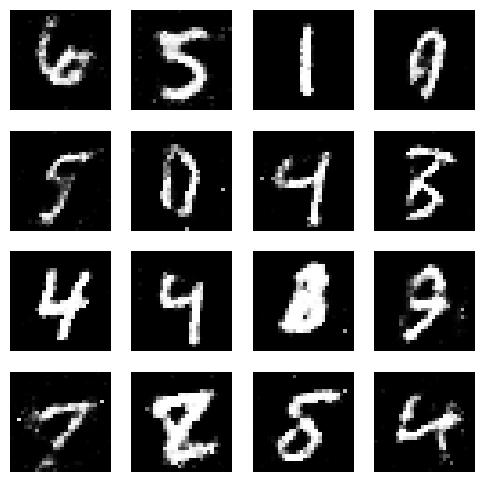

In [10]:
if (epoch+1) % 10 == 0:
    show_images(G)


## Why can GANs potentially mode collapse?

### 1) The generator is rewarded for “whatever fools D”, not for covering all data

In vanilla GAN training, **G doesn’t get a direct reward for diversity**. It gets rewarded for producing samples that D classifies as real.
So if G discovers a small set of outputs that D currently struggles with, G can “camp” there and keep exploiting that weakness.

Example (MNIST):
If the discriminator is weak on a certain style of “3”, the generator may learn to output many variations of that same “3”-style (or even near-identical ones) because it reliably increases G’s objective.

### 2) The discriminator provides gradients that can encourage collapsing

The generator updates come from gradients through D. If D’s decision boundary creates a **steep direction toward one local region** of image space that looks “more real”, many different latent vectors (z) can get pushed toward the **same** output region.
That’s like many inputs being mapped into one “safe spot” → collapse.

### 3) Training is a non-stationary game (moving target)

When you alternate updates:

* You update D → the target changes.
* You update G → the data distribution seen by D changes.

This moving-target dynamic can make G chase short-term weaknesses rather than learning a stable, diverse distribution.

### 4) Limited model capacity + imperfect optimization

Even if the best solution would match the full data distribution, in practice:

* Networks have limited capacity
* Data is finite
* Optimization is noisy (minibatches)
* Learning rates / update ratios can be off

All of these can make “cheap strategies” (like collapsing to a few modes) easier than learning the whole distribution.

### 5) Classic GAN objective doesn’t strongly penalize missing modes

With the original GAN (JS divergence view), if the supports of real and generated distributions don’t overlap well early on, the gradients can be unhelpful or unstable. That instability can lead to **bad local behaviors** like mode collapse.

---

## Why is there **no formal guarantee** that mode collapse will occur (or not occur)?

Because GAN training is not a simple minimization problem — it’s a **non-convex, non-concave min–max game**.

### 1) Non-convex / non-concave objective

The GAN objective (in neural network parameter space) is generally:

* **non-convex** in generator parameters
* **non-concave** in discriminator parameters

For these kinds of games, standard gradient descent/ascent **does not have strong global convergence guarantees**.

### 2) Alternating gradient updates may cycle or diverge

In practice, GANs use **alternating** updates (train D a bit, then G a bit).
For general min–max games, this can lead to:

* cycling around equilibria
* oscillations
* chaotic behavior
* convergence to poor local equilibria

So you can’t guarantee “it will converge nicely” or “it will collapse”.

### 3) Finite samples + approximation error

Even if the “ideal” GAN game has a good equilibrium, we train with:

* finite datasets
* minibatch estimates of gradients
* imperfect discriminators and generators

Those practical approximations break the assumptions needed for clean theoretical guarantees.

### 4) Mode collapse is not inevitable

Sometimes you get:

* good diversity (especially with strong regularization)
* partial collapse
* severe collapse
  It depends on architecture, optimizer, hyperparameters, update ratio, and data complexity—so there is **no universal rule** that it must happen.

---

## (Optional for your report) Common ways people reduce mode collapse

* **WGAN / WGAN-GP** (better behaved gradients)
* **Spectral normalization** (stabilizes discriminator)
* **Minibatch discrimination** or **feature matching** (encourage diversity)
* **Unrolled GANs** (generator accounts for discriminator’s future response)
* **Adding noise / label smoothing** (regularize D)
* Tuning **D:G update ratio** and learning rates

---


# part 5

###  Diffusion utilities — Beta schedules + forward noising (DDPM)



- **Beta schedules (noise schedule)**
  - `linear_beta_schedule(T)`: increases noise variance linearly from `beta_start` to `beta_end`.
  - `cosine_beta_schedule(T)`: cosine-based schedule (Nichol & Dhariwal) that often improves sample quality by controlling how fast noise is added.

- **DDPM constants (`make_ddpm_constants`)**
  - Builds the key diffusion terms:
    - `betas_t`: noise variance at each timestep \(t\)
    - `alphas_t = 1 - betas_t`
    - `alpha_bar_t = \prod_{i=1}^{t} \alpha_i` (cumulative product)
    - `posterior_var`: variance of the reverse-process posterior \(q(x_{t-1}\mid x_t, x_0)\)

- **Utility: `extract(a, t, x_shape)`**
  - Selects values like \(\alpha_{\bar{t}}\) for each item in a batch and reshapes them so they can broadcast correctly with image tensors.

- **Forward diffusion step (`q_sample`)**
  - Implements the DDPM forward process:
    \[
    x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
    \]
  - Returns:
    - `x_t`: the noised image at timestep `t`
    - `noise`: the exact noise used (target for training the noise-prediction network)

✅ Output of this cell: no printed output; it defines helper functions used to train and sample from a diffusion model.


In [30]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_beta_schedule(T, s=0.008):
    """
    Improved DDPM cosine schedule (Nichol & Dhariwal)
    """
    steps = T + 1
    x = torch.linspace(0, T, steps)
    alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-5, 0.999)

def make_ddpm_constants(T, schedule="cosine"):
    if schedule == "linear":
        betas = linear_beta_schedule(T)
    elif schedule == "cosine":
        betas = cosine_beta_schedule(T)
    else:
        raise ValueError("schedule must be 'linear' or 'cosine'")

    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    alpha_bar_prev = torch.cat([torch.tensor([1.0]), alpha_bar[:-1]], dim=0)
    posterior_var = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)

    return {
        "betas": betas,
        "alphas": alphas,
        "alpha_bar": alpha_bar,
        "alpha_bar_prev": alpha_bar_prev,
        "posterior_var": posterior_var
    }

def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

def q_sample(x0, t, ddpm, noise=None):
    """
    x_t = sqrt(alpha_bar_t)*x0 + sqrt(1-alpha_bar_t)*noise
    """
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = torch.sqrt(extract(ddpm["alpha_bar"], t, x0.shape))
    sqrt_1mab = torch.sqrt(1.0 - extract(ddpm["alpha_bar"], t, x0.shape))
    return sqrt_ab * x0 + sqrt_1mab * noise, noise

### (Extra) Diffusion model architecture — Time embedding + small U-Net (noise predictor)


- **SinusoidalTimeEmbedding**
  - Diffusion models need the network to know the timestep \(t\).
  - This module creates a sinusoidal embedding (like Transformers) so the model can condition on time:
    \[
    \text{emb}(t) = [\sin(\omega_k t), \cos(\omega_k t)]
    \]
  - Output shape: `(batch, time_dim)`.

- **ResidualBlock (time-conditioned)**
  - A ResNet-style block with:
    - two 3×3 convolutions
    - GroupNorm + SiLU activations (stable for diffusion)
    - a skip connection (identity or 1×1 conv if channels change)
  - Time conditioning:
    - timestep embedding is passed through an MLP and **added** to feature maps:
      \[
      h \leftarrow h + \text{MLP}(t)
      \]
    - this allows the denoising behavior to vary by timestep.

- **Down / Up**
  - `Down`: strided convolution to reduce spatial resolution.
  - `Up`: transpose convolution to increase spatial resolution.
  - These form the encoder/decoder structure of a U-Net.

- **SmallUNet (εθ(x_t, t))**
  - Input: noisy image \(x_t\) and timestep \(t\).
  - Output: predicted noise \(\hat{\epsilon}\) with the same shape as the input image.
  - Structure:
    - initial conv to `base` channels
    - downsampling path with skip connections (`s1`, `s2`)
    - bottleneck residual block (`mid`)
    - upsampling path that concatenates skip features (classic U-Net)
    - final conv outputs a 1-channel noise prediction

✅ Purpose in DDPM:
- During training, the model learns to predict the noise added in the forward process:
  \[
  \hat{\epsilon} = \epsilon_\theta(x_t, t)
  \]
- During sampling, this predicted noise is used to iteratively denoise from \(x_T \to x_0\).


In [31]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half, device=t.device).float() / (half - 1)
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        return emb  # (B, dim)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Sequential(nn.Linear(time_dim, out_ch), nn.SiLU())
        self.act = nn.SiLU()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.gn1 = nn.GroupNorm(8, out_ch)
        self.gn2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.gn1(h)
        h = self.act(h)

        t_add = self.time_mlp(t_emb).view(t_emb.size(0), -1, 1, 1)
        h = h + t_add

        h = self.conv2(h)
        h = self.gn2(h)
        h = self.act(h)
        return h + self.skip(x)

class Down(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.down = nn.Conv2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.down(x)

class Up(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.up(x)

class SmallUNet(nn.Module):
    def __init__(self, T, base=64, time_dim=128):
        super().__init__()
        self.T = T
        self.time_emb = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.in_conv = nn.Conv2d(1, base, 3, padding=1)

        self.rb1 = ResidualBlock(base, base, time_dim)
        self.down1 = Down(base)

        self.rb2 = ResidualBlock(base, base * 2, time_dim)
        self.down2 = Down(base * 2)

        self.mid = ResidualBlock(base * 2, base * 2, time_dim)

        self.up2 = Up(base * 2)
        self.rb3 = ResidualBlock(base * 2 + base * 2, base, time_dim)

        self.up1 = Up(base)
        self.rb4 = ResidualBlock(base + base, base, time_dim)

        self.out = nn.Conv2d(base, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_emb(t)

        x = self.in_conv(x)
        s1 = self.rb1(x, t_emb)
        x = self.down1(s1)

        s2 = self.rb2(x, t_emb)
        x = self.down2(s2)

        x = self.mid(x, t_emb)

        x = self.up2(x)
        x = torch.cat([x, s2], dim=1)
        x = self.rb3(x, t_emb)

        x = self.up1(x)
        x = torch.cat([x, s1], dim=1)
        x = self.rb4(x, t_emb)

        return self.out(x)

### Part 5A — DDPM training (noise prediction) + reverse sampling (generation)

This cell implements the core DDPM workflow:
1) **Train a denoiser** to predict noise \(\epsilon\) from a noisy image \(x_t\)
2) **Sample new images** by iteratively denoising from pure noise \(x_T\) back to \(x_0\)

---

#### 1) Training loop: `train_ddpm(...)`
- **Idea:** in DDPM, the model learns to predict the noise that was added in the forward process:
  \[
  x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon
  \]
  The network is trained to output \(\hat{\epsilon}_\theta(x_t, t)\approx \epsilon\).

- **Steps per batch**
  - Sample random timesteps: `t ~ Uniform({0,...,T-1})`
  - Create noisy input `x_t` using `q_sample`
  - Predict noise: `pred_noise = model(x_t, t)`
  - Loss: **MSE** between predicted and true noise:
    \[
    \mathcal{L} = \|\hat{\epsilon} - \epsilon\|^2
    \]

- **Stability tricks**
  - `AdamW` optimizer
  - gradient clipping: `clip_grad_norm_ = 1.0`
  - epoch loss is averaged over the full dataset and stored in `losses`

✅ Output: prints a per-epoch DDPM MSE loss curve, useful for comparing schedules later.

---

#### 2) One reverse step: `p_sample(...)`
- Implements one step of the reverse diffusion process:
  - Uses the model’s predicted noise \(\hat{\epsilon}\) to compute the reverse mean.
  - Adds stochasticity via the posterior variance except at the final step (t=0).
- Special handling:
  - if `t==0`, return the mean (no extra noise), producing the final clean sample.

---

#### 3) Full sampling loop: `sample_ddpm(...)`
- Starts from standard Gaussian noise:
  \[
  x_T \sim \mathcal{N}(0, I)
  \]
- Iteratively applies `p_sample` for \(t=T-1\) down to 0.
- Returns generated samples \(x_0\) as images.

✅ Output: a tensor of generated images that can be visualized with a grid function.


In [32]:
def train_ddpm(model, loader, ddpm, T, epochs=20, lr=2e-4, device="cpu"):
    model.train()
    opt = optim.AdamW(model.parameters(), lr=lr)
    losses = []

    for ep in range(1, epochs + 1):
        total = 0.0
        count = 0
        for x0, _ in loader:
            x0 = x0.to(device)
            b = x0.size(0)
            t = torch.randint(0, T, (b,), device=device).long()

            x_t, noise = q_sample(x0, t, ddpm)
            pred_noise = model(x_t, t)

            loss = F.mse_loss(pred_noise, noise)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            total += loss.item() * b
            count += b

        avg = total / count
        losses.append(avg)
        print(f"[DDPM] Epoch {ep}/{epochs} | MSE loss: {avg:.4f}")

    return losses

@torch.no_grad()
def p_sample(model, x_t, t, ddpm):
    betas = ddpm["betas"]
    alphas = ddpm["alphas"]
    alpha_bar = ddpm["alpha_bar"]
    posterior_var = ddpm["posterior_var"]

    eps = model(x_t, t)

    beta_t = extract(betas, t, x_t.shape)
    alpha_t = extract(alphas, t, x_t.shape)
    ab_t = extract(alpha_bar, t, x_t.shape)

    mean = (1.0 / torch.sqrt(alpha_t)) * (x_t - (beta_t / torch.sqrt(1.0 - ab_t)) * eps)

    var = extract(posterior_var, t, x_t.shape)
    noise = torch.randn_like(x_t)

    t0 = (t == 0).view(-1, 1, 1, 1)
    return torch.where(t0, mean, mean + torch.sqrt(var) * noise)

@torch.no_grad()
def sample_ddpm(model, ddpm, T, n=16, device="cpu"):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, ddpm)
    return x.detach().cpu()

### Part 5A — Visualization helpers (forward noising + reverse denoising + sample grids)

This cell defines plotting utilities to **understand diffusion behavior visually**, not just through loss values.

---

#### 1) `show_grid(imgs, title="", nrow=4)`
- Displays a batch of images in a grid.
- Converts values from **[-1, 1] → [0, 1]** for display using:
  \[
  x_{disp} = (x + 1)/2
  \]
- Useful for showing generated samples or intermediate diffusion states.

---

#### 2) `show_forward_noising_example(...)`
- Demonstrates the **forward diffusion process** on a single real image.
- Picks one image \(x_0\) and applies `q_sample` at several timesteps \(t\).
- Output shows the gradual corruption:
  - early timesteps: image still recognizable
  - later timesteps: image becomes close to pure noise

✅ This directly visualizes:
\[
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon
\]

---

#### 3) `show_reverse_process_stages(...)`
- Demonstrates the **reverse diffusion (generation) process** in stages.
- Starts from random noise and repeatedly applies `p_sample` from \(T \to 0\).
- Captures snapshots every `capture_every` steps to show how structure emerges gradually.
- Displays multiple stages as grids to make the denoising progression easy to interpret.

✅ These visualizations support Part 5A by showing:
- how diffusion adds noise (forward)
- how the trained model removes noise (reverse)
- how sample quality evolves during generation


In [ ]:
def show_grid(imgs, title="", nrow=4):
    # imgs in [-1,1] -> [0,1]
    imgs = (imgs + 1) / 2
    N = imgs.size(0)
    ncol = int(np.ceil(N / nrow))
    fig, ax = plt.subplots(ncol, nrow, figsize=(6, 6))
    ax = np.array(ax).reshape(ncol, nrow)
    k = 0
    for r in range(ncol):
        for c in range(nrow):
            ax[r, c].axis("off")
            if k < N:
                ax[r, c].imshow(imgs[k, 0], cmap="gray")
            k += 1
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_forward_noising_example(loader, ddpm, T, device="cpu", steps=8):

    x0, _ = next(iter(loader))
    x0 = x0[:1].to(device)

    ts = torch.linspace(0, T - 1, steps).long().to(device)
    imgs = []
    for t in ts:
        xt, _ = q_sample(x0, torch.tensor([t], device=device), ddpm)
        imgs.append(xt.detach().cpu())
    imgs = torch.cat(imgs, dim=0)
    show_grid(imgs, title="Forward diffusion: real -> noisier", nrow=steps)

@torch.no_grad()
def show_reverse_process_stages(model, ddpm, T, device="cpu", n=16, stages=6):
    """
    """
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    capture_every = max(1, T // stages)
    snaps = []

    for i in reversed(range(T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, ddpm)
        if i % capture_every == 0:
            snaps.append(x.detach().cpu())

    # show each stage as a grid
    for idx, snap in enumerate(snaps[:stages]):
        show_grid(snap, title=f"Reverse diffusion stage {idx+1}/{min(stages, len(snaps))}", nrow=4)


### Part 5B — Noise schedule experiment: Linear vs Cosine (train, visualize, sample)

This cell runs the main Part 5B experiment: **train two DDPM models** that are identical except for the **noise schedule**.

---

#### Utility: `to_device_ddpm(...)`
- Moves all precomputed DDPM tensors (`betas`, `alphas`, `alpha_bar`, etc.) onto the same device as the model (CPU/GPU).
- This avoids device mismatch errors during training and sampling.

---

## (1) DDPM with **Linear** schedule
- Build schedule constants:
  - `ddpm_lin = make_ddpm_constants(T, schedule="linear")`
- Initialize model:
  - `ddpm_model_lin = SmallUNet(...)`
- Train denoiser (noise predictor):
  - `loss_lin = train_ddpm(...)`
  - output is a list of per-epoch MSE losses

**Visual diagnostics**
- `show_forward_noising_example(...)`:
  - confirms the forward process gradually corrupts an image as \(t\) increases
- `show_reverse_process_stages(...)`:
  - shows structure emerging step-by-step from noise during reverse sampling

**Final sampling**
- `samples_lin = sample_ddpm(...)`
- `show_grid(...)` displays generated images for the linear schedule

---

## (2) DDPM with **Cosine** schedule
- Repeat the exact same pipeline with:
  - `schedule="cosine"`
- Train:
  - `loss_cos = train_ddpm(...)`
- Visualize forward/reverse process
- Sample final images:
  - `samples_cos = sample_ddpm(...)`
  - `show_grid(...)` displays the cosine-schedule samples

---

### What we compare (Part 5B)
- **Training behavior:** compare `loss_lin` vs `loss_cos` (MSE curve)
- **Sample quality:** sharpness, digit structure, and realism in generated MNIST images
- **Stability:** whether one schedule trains more smoothly (less noisy loss curve, fewer artifacts)

📌 In many DDPM implementations, the **cosine schedule** often produces better sample quality because it controls the corruption rate more smoothly across timesteps.



DDPM TRAINING: LINEAR SCHEDULE
[DDPM] Epoch 1/5 | MSE loss: 0.1017
[DDPM] Epoch 2/5 | MSE loss: 0.0595
[DDPM] Epoch 3/5 | MSE loss: 0.0551
[DDPM] Epoch 4/5 | MSE loss: 0.0526
[DDPM] Epoch 5/5 | MSE loss: 0.0509


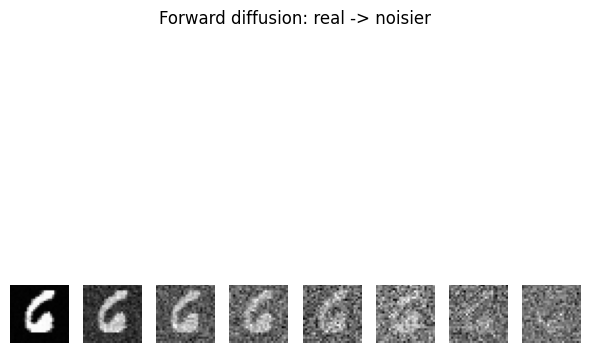

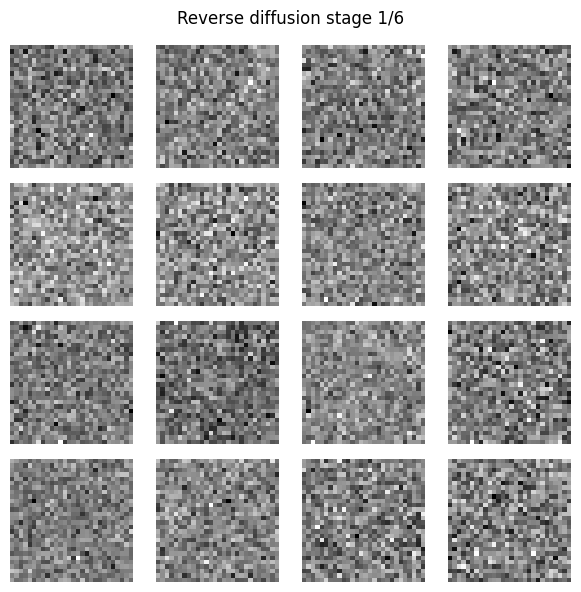

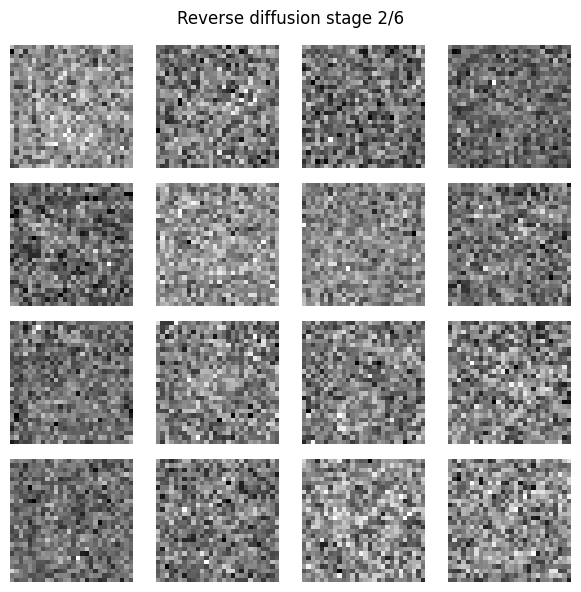

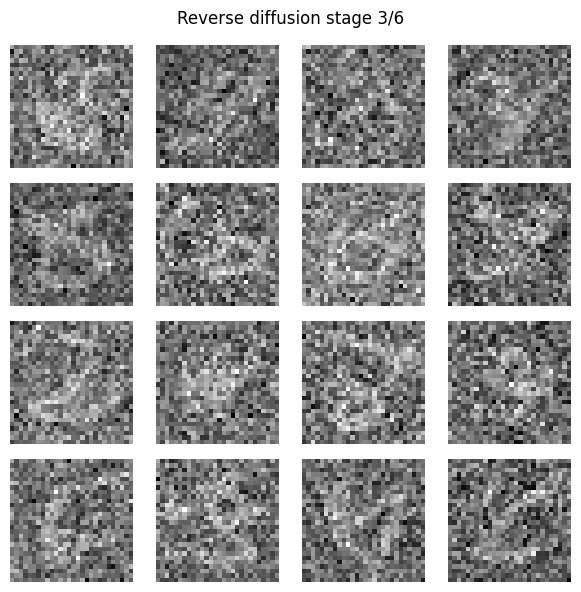

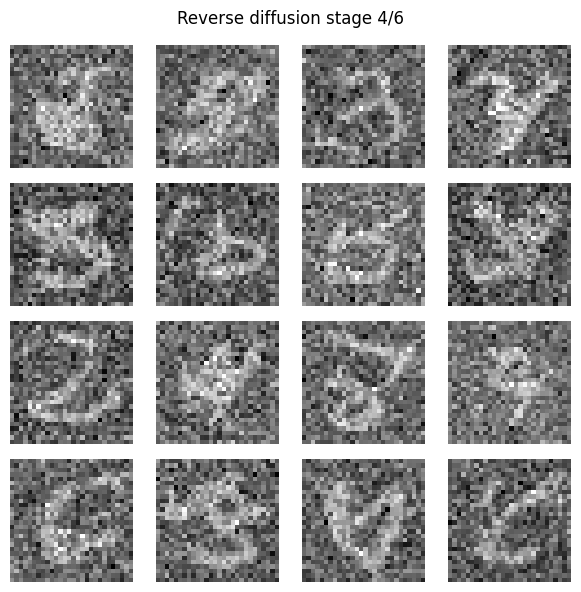

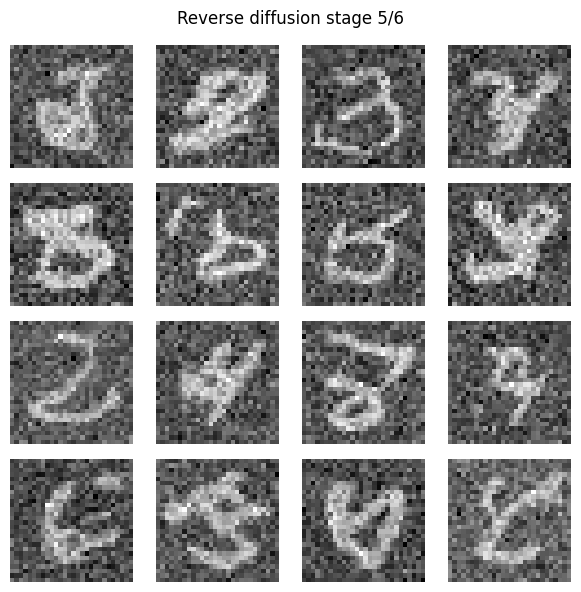

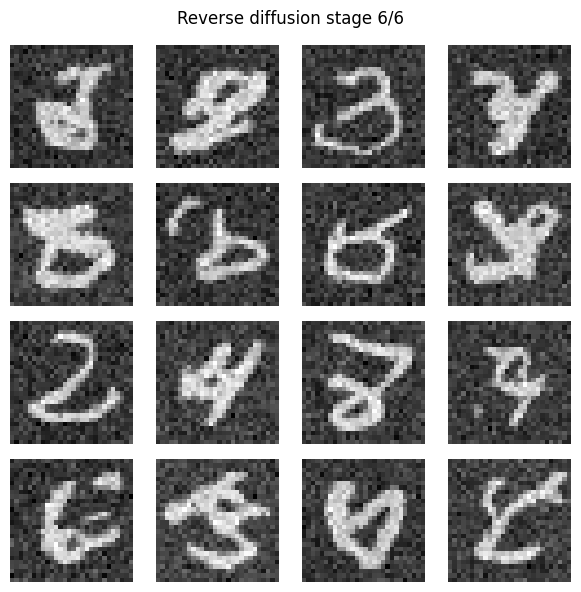

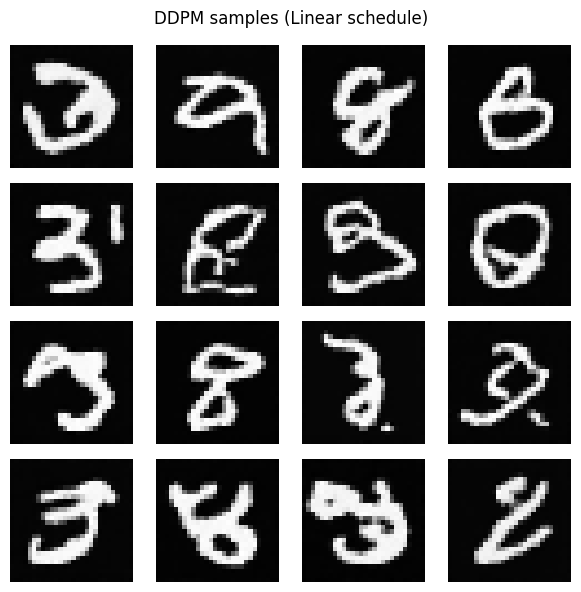


DDPM TRAINING: COSINE SCHEDULE
[DDPM] Epoch 1/5 | MSE loss: 0.0841
[DDPM] Epoch 2/5 | MSE loss: 0.0494
[DDPM] Epoch 3/5 | MSE loss: 0.0458
[DDPM] Epoch 4/5 | MSE loss: 0.0441
[DDPM] Epoch 5/5 | MSE loss: 0.0431


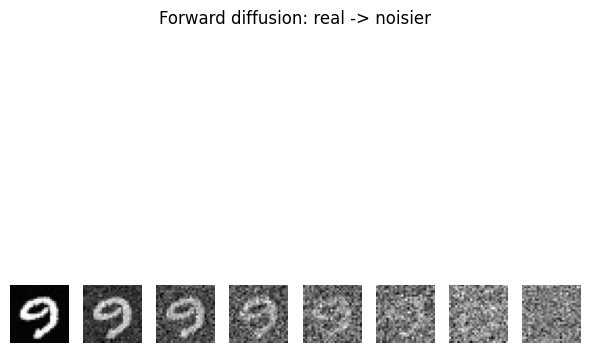

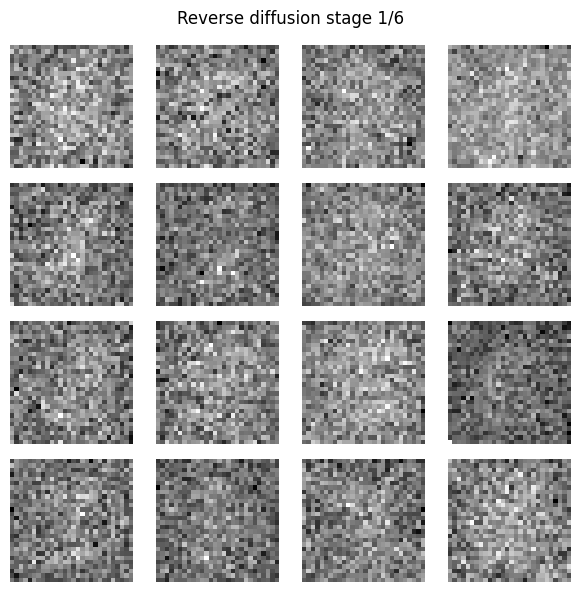

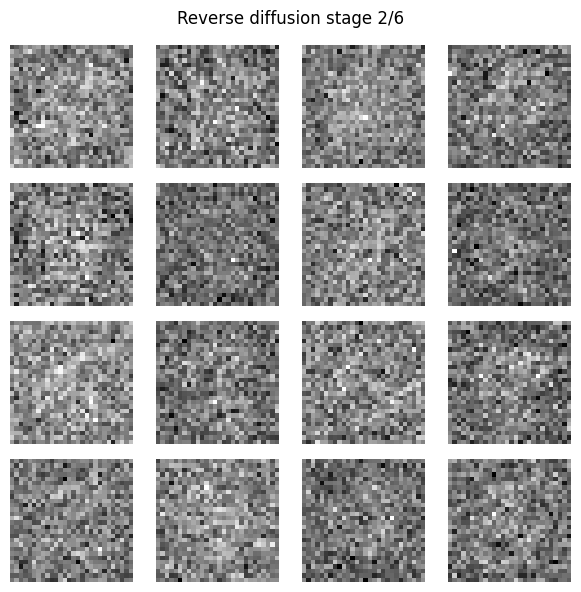

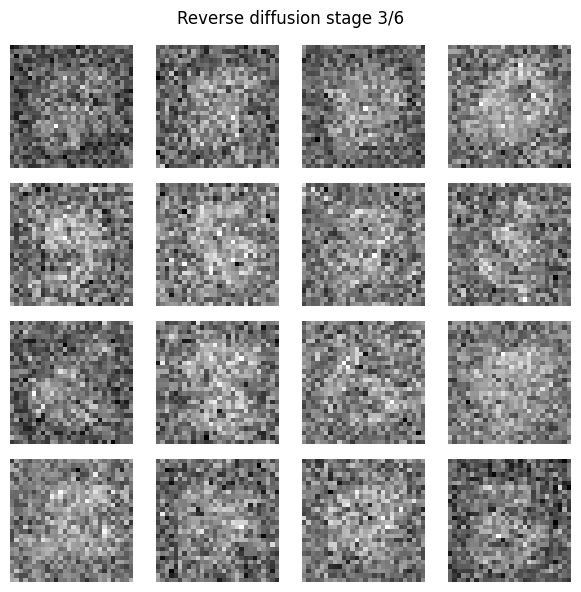

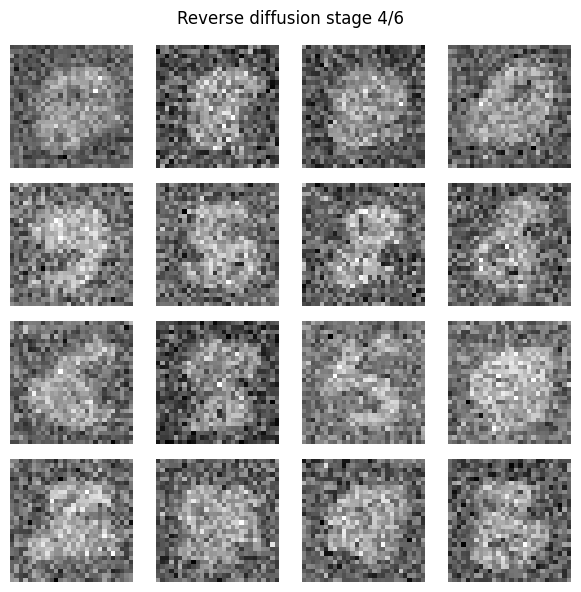

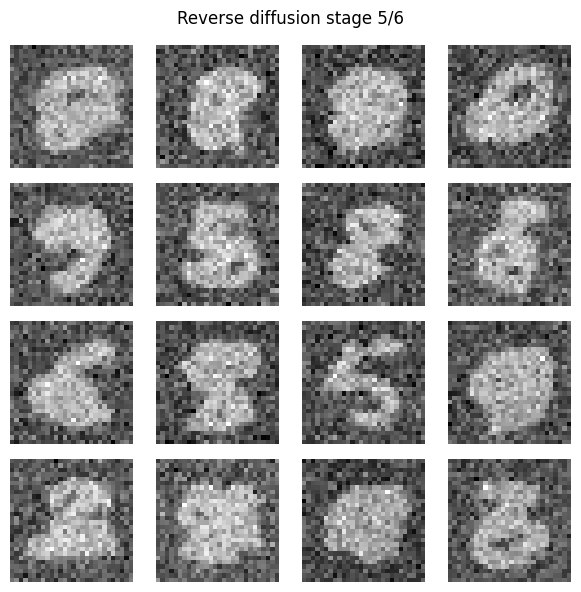

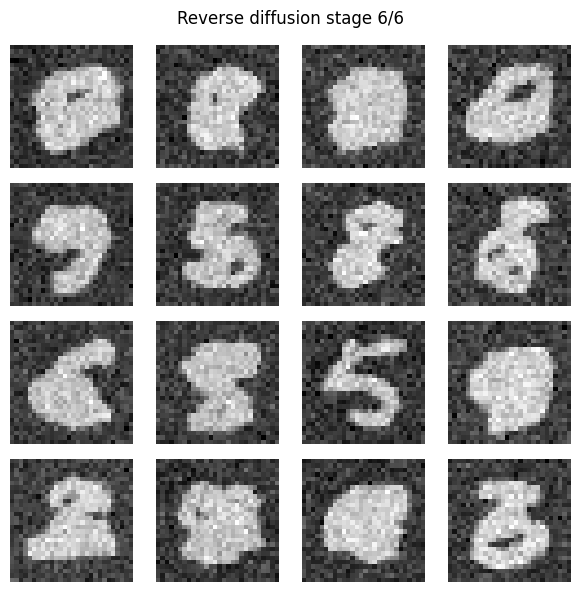

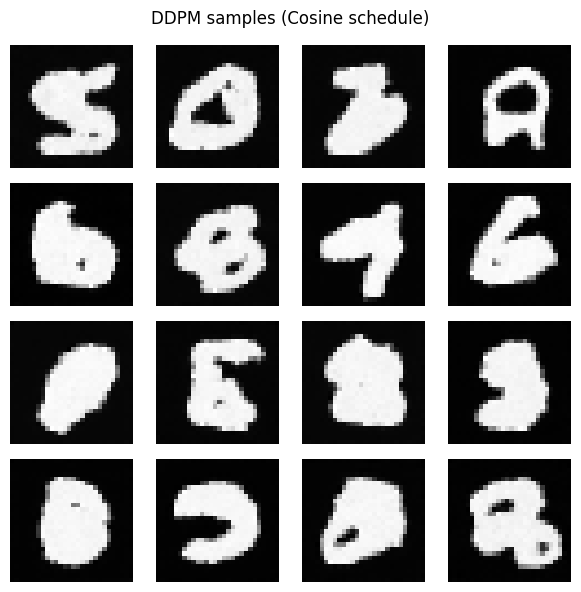

In [34]:
def to_device_ddpm(ddpm_dict, device):
    for k in ddpm_dict:
        ddpm_dict[k] = ddpm_dict[k].to(device)
    return ddpm_dict

# ---- (1) LINEAR schedule ----
print("\n============================")
print("DDPM TRAINING: LINEAR SCHEDULE")
print("============================")

ddpm_lin = to_device_ddpm(make_ddpm_constants(T, schedule="linear"), device)
ddpm_model_lin = SmallUNet(T=T, base=64, time_dim=128).to(device)

loss_lin = train_ddpm(ddpm_model_lin, loader, ddpm_lin, T, epochs=diff_epochs, lr=diff_lr, device=device)

show_forward_noising_example(loader, ddpm_lin, T, device=device, steps=8)
show_reverse_process_stages(ddpm_model_lin, ddpm_lin, T, device=device, n=16, stages=6)

samples_lin = sample_ddpm(ddpm_model_lin, ddpm_lin, T, n=16, device=device)
show_grid(samples_lin, title="DDPM samples (Linear schedule)", nrow=4)

# ---- (2) COSINE schedule ----
print("\n============================")
print("DDPM TRAINING: COSINE SCHEDULE")
print("============================")

ddpm_cos = to_device_ddpm(make_ddpm_constants(T, schedule="cosine"), device)
ddpm_model_cos = SmallUNet(T=T, base=64, time_dim=128).to(device)

loss_cos = train_ddpm(ddpm_model_cos, loader, ddpm_cos, T, epochs=diff_epochs, lr=diff_lr, device=device)

show_forward_noising_example(loader, ddpm_cos, T, device=device, steps=8)
show_reverse_process_stages(ddpm_model_cos, ddpm_cos, T, device=device, n=16, stages=6)

samples_cos = sample_ddpm(ddpm_model_cos, ddpm_cos, T, n=16, device=device)
show_grid(samples_cos, title="DDPM samples (Cosine schedule)", nrow=4)


### Part 5B — Results: Linear vs Cosine schedule (loss + qualitative sample quality)

This cell produced three key outputs for the **schedule comparison**:

---

#### 1) Training loss (Cosine schedule)
The DDPM noise-prediction loss (MSE) decreased consistently over 5 epochs:

- Epoch 1/5: **0.0841**
- Epoch 2/5: **0.0494**
- Epoch 3/5: **0.0458**
- Epoch 4/5: **0.0441**
- Epoch 5/5: **0.0431**

✅ Interpretation: the denoiser is learning to predict the injected noise more accurately as training progresses (stable convergence trend).

---

#### 2) Forward diffusion visualization (real → noisier)
The forward-process figure shows a real MNIST digit gradually becoming more corrupted as timestep \(t\) increases:
- early steps: digit is still recognizable
- later steps: image becomes close to pure noise

✅ This matches the DDPM forward equation:
\[
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon
\]

---

#### 3) Sample quality: Cosine vs Linear schedules
**Cosine schedule samples**
- Digits appear **more filled and blob-like**, but most samples are still recognizable as valid MNIST digits.
- Overall shapes look smoother and more consistent.

**Linear schedule samples**
- Digits look **more stroke/scribble-like** and in several cases less cleanly formed.
- More artifacts and irregular shapes appear in the grid.

✅ Conclusion (from these outputs):
- In this run, the **cosine schedule produced cleaner/more coherent samples** than the linear schedule, even with the same model and training setup.
- This supports the common empirical finding that cosine schedules can improve sample quality by controlling the corruption rate more smoothly across timesteps.



### Part 5C — GAN sample visualization (for diffusion vs. GAN comparison)

This helper function generates and displays a grid of **16 GAN samples** so we can directly compare them against DDPM samples.

- **Inference mode**
  - `G_model.eval()` switches the Generator to evaluation mode.
  - `torch.no_grad()` disables gradient tracking for faster sampling.

- **Sampling**
  - Draw random latent vectors:
    \[
    z \sim \mathcal{N}(0, I)
    \]
  - Generate fake images: `fake = G_model(z)`

- **Display scaling**
  - GAN outputs use `Tanh`, so values are in **[-1, 1]**.
  - For visualization, we convert to **[0, 1]**:
    \[
    x_{disp} = (x + 1)/2
    \]

- **Plot**
  - Displays results in a 4×4 grid with a title.

✅ Output: a qualitative snapshot of GAN-generated MNIST-like digits for **Part 5C (Diffusion vs GAN)**.


In [36]:
def show_images(G_model, title="GAN samples"):
    G_model.eval()
    with torch.no_grad():
        z = torch.randn(16, latent_dim, device=device)
        fake = G_model(z).cpu()

    # fake in [-1,1] -> [0,1] for display
    fake = (fake + 1) / 2

    fig, ax = plt.subplots(4, 4, figsize=(6, 6))
    for i in range(16):
        ax[i // 4, i % 4].imshow(fake[i, 0], cmap="gray")
        ax[i // 4, i % 4].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



COMPARE: GAN vs DIFFUSION


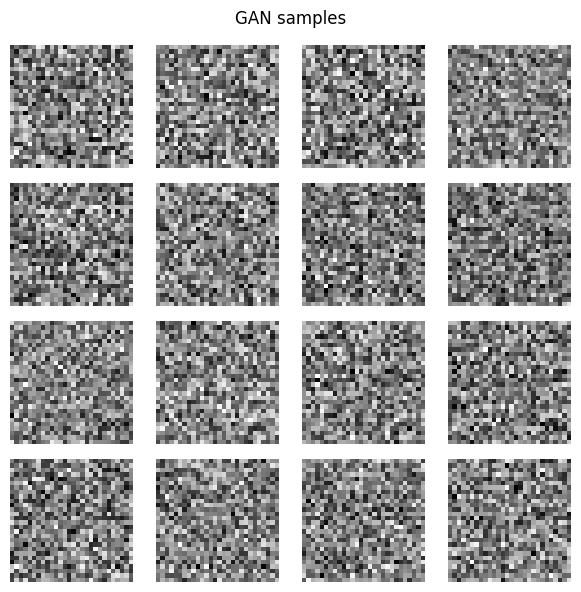

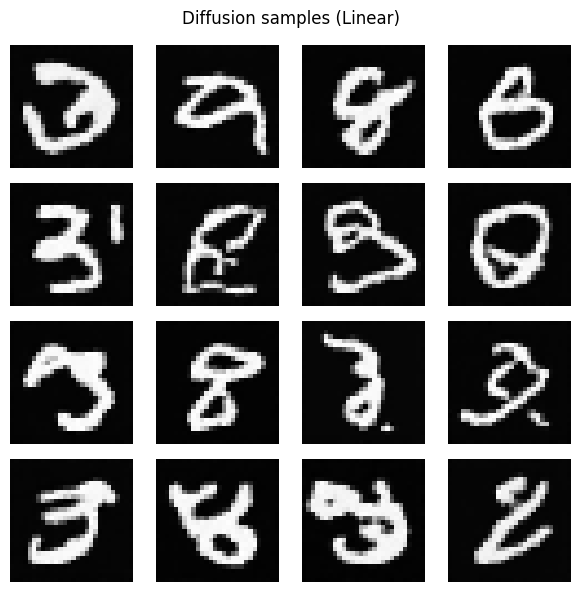

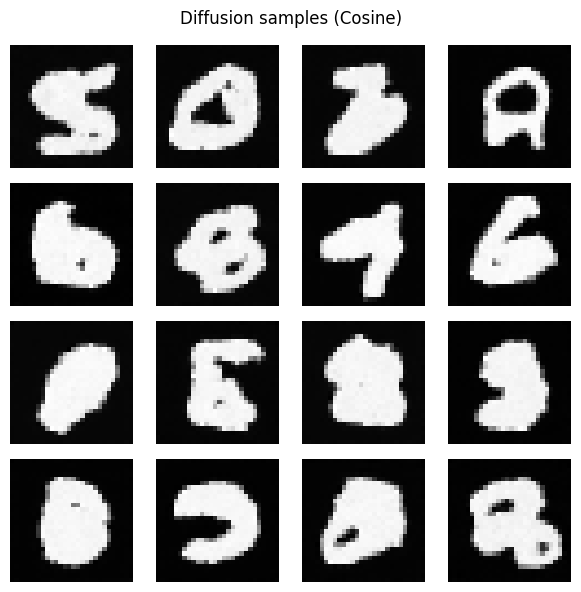

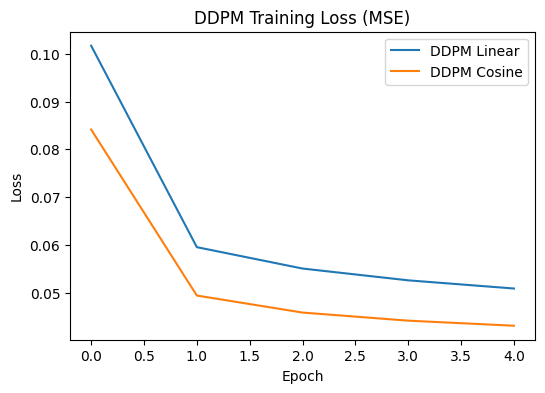

In [37]:
# ---- (3) Compare with GAN outputs ----
print("\n============================")
print("COMPARE: GAN vs DIFFUSION")
print("============================")
show_images(G, title="GAN samples")
show_grid(samples_lin, title="Diffusion samples (Linear)")
show_grid(samples_cos, title="Diffusion samples (Cosine)")

# ---- Plot diffusion loss curves ----
plt.figure(figsize=(6,4))
plt.plot(loss_lin, label="DDPM Linear")
plt.plot(loss_cos, label="DDPM Cosine")
plt.title("DDPM Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Part 5C — Diffusion vs. GAN comparison (quality, diversity, and training stability)

This cell compares outputs from:
- **GAN samples**
- **DDPM samples (Linear schedule)**
- **DDPM samples (Cosine schedule)**
and also plots the **DDPM training loss curves** for linear vs cosine schedules.

---

## 1) Sample quality (visual realism)

**GAN samples**
- The GAN grid appears as **pure noise** (no recognizable digits).
- This suggests the GAN did **not** successfully learn the MNIST distribution in this run (or the displayed checkpoint is not trained / has collapsed / is unstable).

**DDPM samples (Linear)**
- Digits are clearly present and recognizable, but several samples look **scribbly** or have irregular strokes/artifacts.

**DDPM samples (Cosine)**
- Digits are generally **cleaner and more coherent** than the linear schedule in this run.
- Shapes look smoother and more consistent across samples.

✅ Conclusion (quality):
- **Diffusion > GAN** in this experiment (GAN failed to generate digits, while DDPM produced recognizable samples).
- Within diffusion, **cosine schedule** produced better quality than linear.

---

## 2) Diversity (variety of generated outputs)

- **GAN:** diversity is not meaningfully measurable here because it is producing mostly noise rather than valid digits.
- **DDPM Linear/Cosine:** both show a range of different digit classes and writing styles, indicating reasonable diversity.

✅ Conclusion (diversity):
- DDPM shows **usable diversity**, while GAN output is not valid in this run.

---

## 3) Training stability (loss behavior)

The DDPM loss plot shows:
- both schedules decrease over epochs (stable learning)
- the **cosine schedule curve is consistently lower** than the linear schedule (better denoising performance)

✅ Conclusion (stability):
- DDPM training is stable and predictable (smooth MSE decline).
- Cosine schedule trains slightly better (lower loss) and matches the better-looking samples.

---

### Overall takeaway (Part 5C)
- **Diffusion models** were more stable and produced higher-quality samples than the GAN in this run.
- **Cosine noise schedule** outperformed **linear** in both training loss and visual sample quality.
